# Experimenting with edge counts on n dimensionsl hypershpere (uniform)

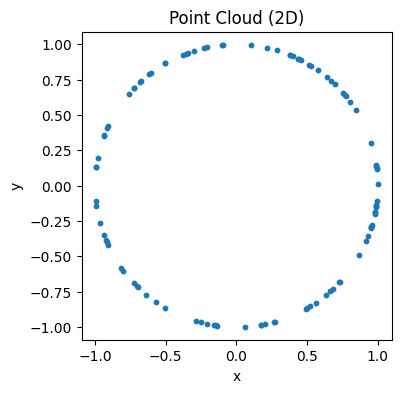

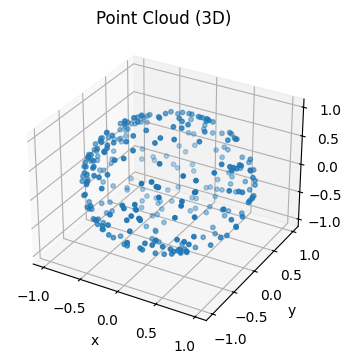

In [1]:
import numpy as np
import ecc_vr as vr
import matplotlib.pyplot as plt

def unif_hypershphere_pc(n_points, d, r = 1.0, center = None, seed = None):
    # generate points uniformly on surface of n-dimensional hypershpere
    # params: n_points (number of points), d (dimension), r (radius), center (if none uses origin)
    # returns: ndarray of shape (n_points, d)

    rng = np.random.default_rng(seed)

    #sample from standard normal and normalize
    points = rng.normal(size=(n_points,d))
    points /= np.linalg.norm(points,axis=1,keepdims = True)

    #scale to radius
    points *= r

    #shift to center
    if center is not None:
        center = np.asarray(center)
        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")
        points += center

    return points

C = unif_hypershphere_pc(n_points = 100, d = 2, r = 1, seed = 123)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
vr.plot_point_cloud_on_ax(ax, C, 2)
plt.show()

C2 = unif_hypershphere_pc(n_points = 300, d = 3, r = 1, seed = 234)
fig2 = plt.figure(figsize = (4,4))
ax2 = fig2.add_subplot(111, projection = '3d')
vr.plot_point_cloud_on_ax(ax2, C2, 3)
plt.show()


In [2]:
def count_edges(X: np.ndarray, epsilon: float, D: np.ndarray | None = None) -> int:
    X = np.asarray(X, dtype = float)

    if D is None:
        D = vr.pairwise_dist(X)
    
    edge_count = int(np.count_nonzero(np.triu(D <= epsilon, k = 1)))
    return edge_count

print(count_edges(C, epsilon = 0.4))

print(count_edges(C2, epsilon = 0.4))

612
1865


In [3]:
def edge_count_sim_hypersphere(
        n_points: int,
        d: int,
        t: float,
        n_resamples: int,
        r: float = 1.0,
        seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)

    edge_counts = np.empty(n_resamples, dtype = int)
    epsilon = t /(n_points ** (1/(d-1)))

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0,1_000_000_000))
        X = unif_hypershphere_pc(
            n_points = n_points, 
            d = d,
            r = r, 
            seed = sample_seed)
        edge_counts[i] = count_edges(X, epsilon)

    return edge_counts

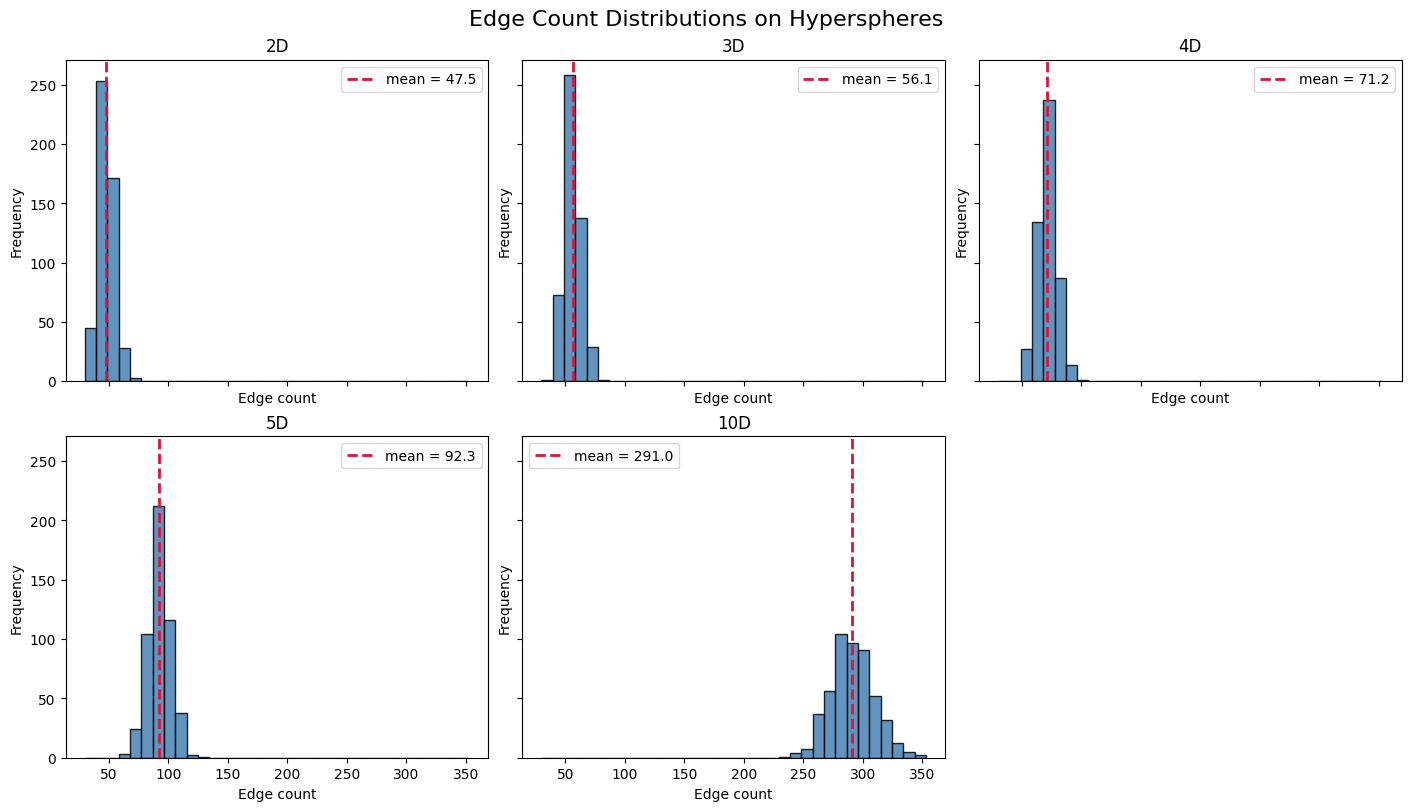

In [7]:
dims = [2, 3, 4, 5, 10]

# Run simulations first
results = {
    d: edge_count_sim_hypersphere(
        n_points=200,
        d=d,
        t=1.5,
        n_resamples=500,
        r=1,
        seed=453
    )
    for d in dims
}

# Use common bins across all panels for fair comparison
all_counts = np.concatenate(list(results.values()))
bins = np.linspace(all_counts.min(), all_counts.max(), 35)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()

for ax, d in zip(axes, dims):
    counts = results[d]
    ax.hist(counts, bins=bins, color="steelblue", edgecolor="black", alpha=0.85)
    ax.axvline(counts.mean(), color="crimson", linestyle="--", linewidth=2, label=f"mean = {counts.mean():.1f}")
    ax.set_title(f"{d}D")
    ax.set_xlabel("Edge count")
    ax.set_ylabel("Frequency")
    ax.legend()

# Hide the unused 6th subplot
axes[-1].axis("off")

fig.suptitle("Edge Count Distributions on Hyperspheres", fontsize=16)
plt.show()

When d increases, two random points on the sphere become more orthogonal. Thus, their dot product is then close to 0 and their distance is close to $\sqrt{2}r$. So in higher dimensions most pairs of points sit at about the same distance. If we want a fair comparison between dimensions that we should try to keep the connectivity level fixed, not $\varepsilon$. 

If each points should have an average of k_target neighbors, then for any fixed pair of points the target connection probability is 

$$
p_{\text{target}} = \frac{k_{\text{target}}}{n-1}.
$$

If we instead start from a target mean total edge count edge_target, then 

$$
k_{\text{target}} = \frac{2\,\text{edge}_{\text{target}}}{n},
\qquad
p_{\text{target}} = \frac{2\,\text{edge}_{\text{target}}}{n(n-1)}.
$$

So in this specific case with $n= 500$ and a target mean edge count of about $887.1$ we have,

$$
k_{\text{target}} = \frac{2(887.1)}{500} \approx 3.55.
$$

So each point should have about $3.55$ neigbors on average. 

Now, for two independent points $X,Y$ on the sphere $S^{d-1}(r)$, define

$$
U = \frac{1 + (X \cdot Y)/r^2}{2}.
$$

This rescales the dot product into the interval $[0,1]$ and note that we have

$$
U \sim \mathrm{Beta}\left(\frac{d-1}{2}, \frac{d-1}{2}\right).
$$

and

$$
\|X - Y\|^2 = 2r^2 - 2X \cdot Y.
$$

So after rewriting in terms of U,

$$
\|X - Y\| = 2r\sqrt{1-U}.
$$

So two points are connected when

$$
\|X - Y\| \le \varepsilon
\iff
U \ge 1 - \frac{\varepsilon^2}{4r^2}.
$$

So the connection probability is

$$
p_d(\varepsilon) = \Pr\left(U \ge 1 - \frac{\varepsilon^2}{4r^2}\right).
$$

To force the same expected connectivity across dimensions, set this equal to the target probability:


$$
p_d(\varepsilon_d) = p_{\text{target}}.
$$

Let

$$
a = \frac{d-1}{2}.
$$

Then solving yields

$$
\varepsilon_d = 2r\sqrt{1 - F^{-1}_{\mathrm{Beta}(a,a)}(1-p_{\text{target}})}.
$$




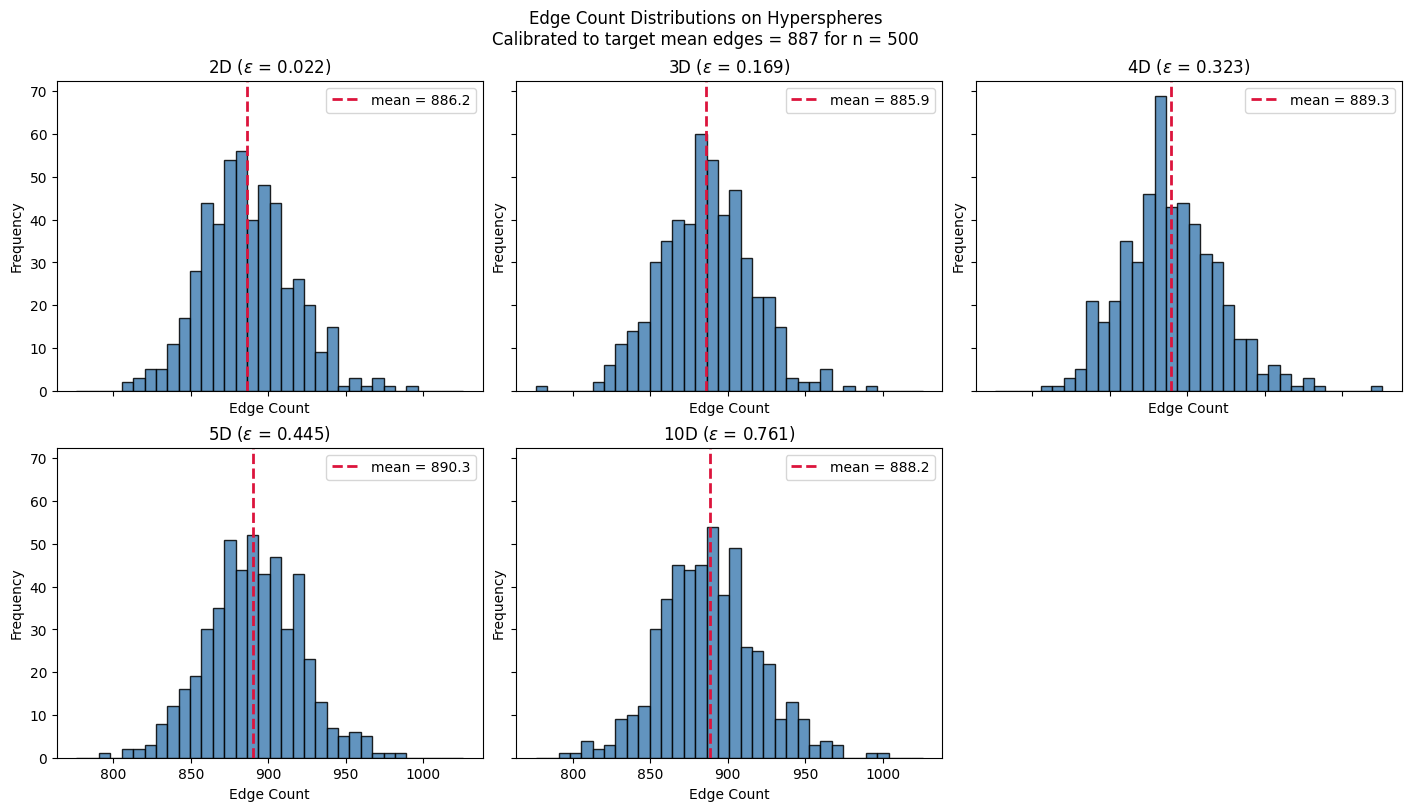

d = 2: epsilon = 0.0223, mean = 886.2, std = 29.2
d = 3: epsilon = 0.1686, mean = 885.9, std = 29.3
d = 4: epsilon = 0.3232, mean = 889.3, std = 30.6
d = 5: epsilon = 0.4450, mean = 890.3, std = 30.0
d = 10: epsilon = 0.7606, mean = 888.2, std = 31.4


In [5]:
import math
from scipy.stats import beta

dims = [2,3,4,5,10]
n_points = 500
n_resamples = 500
edge_target = 887.0  # target mean edge count from the 2D baseline
r = 1.0
seed = 453

def calibrate_epsilon_for_edge_target(n_points: int, d: int, edge_target: float, r: float = 1.0) -> float:
    # Points live on S^(d-1), so the pairwise-angle law determines the connection probability.
    p_target = 2 * edge_target / (n_points * (n_points - 1))
    a = (d - 1) / 2
    u = beta.ppf(1 - p_target, a, a)
    return 2 * r * math.sqrt(1 - u)

def edge_count_sim_hypersphere_epsilon(
        n_points: int,
        d: int,
        epsilon: float,
        n_resamples: int,
        r: float = 1.0,
        seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype = int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))
        X = unif_hypershphere_pc(
            n_points = n_points,
            d = d,
            r = r,
            seed = sample_seed,
        )
        edge_counts[i] = count_edges(X, epsilon)

    return edge_counts

epsilons = {
    d: calibrate_epsilon_for_edge_target(n_points = n_points, d = d, edge_target = edge_target, r = r)
    for d in dims
}

results = {
    d: edge_count_sim_hypersphere_epsilon(
        n_points = n_points,
        d = d,
        epsilon = epsilons[d],
        n_resamples = n_resamples,
        r = r,
        seed = seed,
    )
    for d in dims
}

# Use common bins across all panels for comparison.
all_counts = np.concatenate(list(results.values()))
bins = np.linspace(all_counts.min(), all_counts.max(), 35)

fig, axes = plt.subplots(2, 3, figsize=(14,8), sharex = True, sharey = True, constrained_layout = True)
axes = axes.ravel()

for ax, d in zip(axes, dims):
    counts = results[d]
    ax.hist(counts, bins = bins, color = "steelblue", edgecolor = "black", alpha = 0.85)
    ax.axvline(counts.mean(), color = "crimson", linestyle = "--", linewidth = 2, label = f"mean = {counts.mean():.1f}")
    ax.set_title(f"{d}D ($\\varepsilon$ = {epsilons[d]:.3f})")
    ax.set_xlabel("Edge Count")
    ax.set_ylabel("Frequency")
    ax.legend()

axes[-1].axis("off")

fig.suptitle(f"Edge Count Distributions on Hyperspheres\nCalibrated to target mean edges = {edge_target:.0f} for n = {n_points}")
plt.show()

for d in dims:
    counts = results[d]
    print(f"d = {d}: epsilon = {epsilons[d]:.4f}, mean = {counts.mean():.1f}, std = {counts.std(ddof = 1):.1f}")

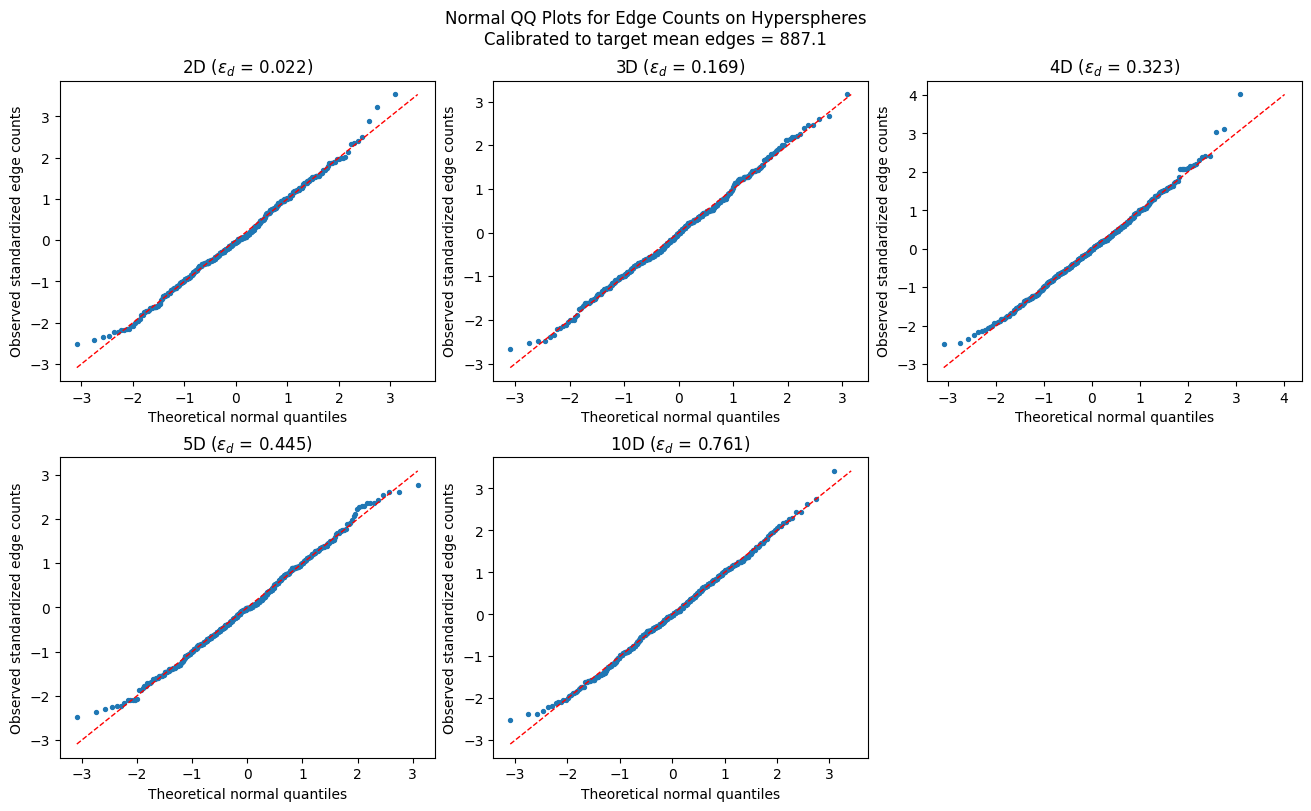

In [6]:
from statistics import NormalDist

edge_target = 887.1
n_points = 500
n_resamples = 500
dims = [2, 3, 4, 5, 10]
r = 1.0
seed = 453

epsilons = {
    d: calibrate_epsilon_for_edge_target(n_points, d, edge_target, r)
    for d in dims
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()

for ax, d in zip(axes, dims):
    counts = edge_count_sim_hypersphere_epsilon(
        n_points=n_points,
        d=d,
        epsilon=epsilons[d],
        n_resamples=n_resamples,
        r=r,
        seed=seed + d,
    )

    mu = counts.mean()
    sd = counts.std(ddof=1)

    z = np.sort((counts - mu) / sd)
    p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    q = np.array([NormalDist().inv_cdf(pi) for pi in p])

    lo = min(q.min(), z.min())
    hi = max(q.max(), z.max())

    ax.scatter(q, z, s=8)
    ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
    ax.set_title(f"{d}D ($\\varepsilon_d$ = {epsilons[d]:.3f})")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Observed standardized edge counts")

axes[-1].axis("off")

fig.suptitle(
    f"Normal QQ Plots for Edge Counts on Hyperspheres\n"
    f"Calibrated to target mean edges = {edge_target:.1f}"
)
plt.show()